In [1]:
import sys
sys.path.insert(0, '../src')

import torch
import matplotlib.pyplot as plt
from pathlib import Path

from diffusion_ebm.models import EBM
from diffusion_ebm.ema import EMA
from diffusion_ebm.langevin import langevin_sample_train
from diffusion_ebm.train_ebm import show_replay_buffer_samples

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

Using device: cuda


In [2]:
# CHECKPOINT_PATH = Path('../checkpoints/model_test/step_110000.pt')
CHECKPOINT_PATH = Path('../checkpoints/nicer_lr_schedule/step_30000.pt')

model = EBM(img_size=32, in_channels=1, ch=16, n_downsamples=2).to(device)
model_ema = EMA(model, decay=0.999, burn_in=500)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model_ema.shadow = {k: v.to(device) for k, v in ckpt['ema_shadow'].items()}  # must load BEFORE apply_shadow()
buffer = ckpt['replay_buffer']

print('Loaded:', CHECKPOINT_PATH)
print('Training step:', ckpt['state']['step'])

Loaded: ..\checkpoints\nicer_lr_schedule\step_30000.pt
Training step: 30000


Buffer size: 8192


(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Samples from Replay Buffer'}>)

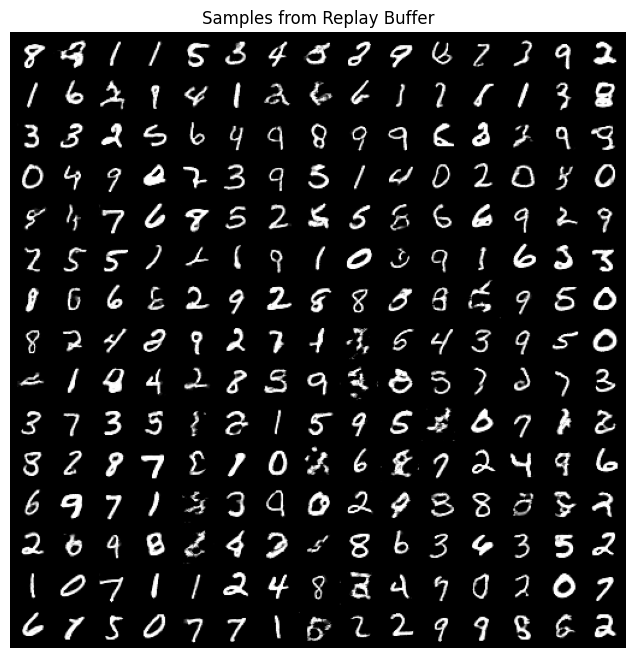

In [3]:
print('Buffer size:', len(buffer))
# Buffer stores images in [-1, 1]; convert to [0, 1] before passing to the classifier
get_image = (buffer[:1000].clamp(-1, 1) + 1) / 2
show_replay_buffer_samples(buffer[:1000])  # show raw buffer (still [-1,1], as expected)

In [4]:
# get_image.shape
# get_image[888][0].shape
# torch.set_printoptions(threshold=10_000, linewidth=200)
# print(get_image[0][0])

### IS

In [4]:
@torch.no_grad()
def get_probs_from_classifier(clf, images, device, batch_size=128):
    clf = clf.to(device).eval()
    probs_list = []
    for i in range(0, images.size(0), batch_size):
        x = images[i:i+batch_size].to(device)   # [B,1,H,W] in [0,1]
        x = x * 2.0 - 1.0                       # -> [-1,1], match classifier training
        if x.shape[-1] != 28:                    # EBM uses 32x32; classifier expects 28x28
            x = F.interpolate(x, size=(28, 28), mode='bilinear', align_corners=False)
        logits = clf(x)
        probs = F.softmax(logits, dim=1)
        probs_list.append(probs)
    return torch.cat(probs_list, dim=0)


def inception_score_from_probs(probs, splits=10, eps=1e-16):
    """
    probs: torch.Tensor [N, K], each row sums to 1
    IS = exp(E_x KL(p(y|x) || p(y)))
    returns (mean, std) across splits
    """
    probs = probs.detach().cpu()
    N = probs.size(0)

    assert N >= splits, "Need N >= splits"
    assert N % splits == 0, f"N ({N}) must be divisible by splits ({splits})"

    split_size = N // splits
    scores = []

    for s in range(splits):
        part = probs[s*split_size:(s+1)*split_size]         # [split_size, K]
        py = part.mean(dim=0, keepdim=True)                 # [1, K]
        kl = part * (torch.log(part + eps) - torch.log(py + eps))  # [split_size, K]
        kl = kl.sum(dim=1).mean()                           # scalar
        scores.append(torch.exp(kl).item())

    scores_t = torch.tensor(scores)
    return scores_t.mean().item(), scores_t.std(unbiased=False).item()


def compute_is_for_ddpm_samples(images, clf, device=None, batch_size=128, splits=10):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    probs = get_probs_from_classifier(clf, images, device=device, batch_size=batch_size)
    is_mean, is_std = inception_score_from_probs(probs, splits=splits)
    print(f"Inception Score (using your ResNetMini classifier): {is_mean:.4f} ± {is_std:.4f}")
    return is_mean, is_std, probs

In [5]:
from src.assignment1.classifier.helper import load_classifier
import torch.nn.functional as F

my_model = load_classifier()

Successfully loaded model from checkpoints/classifier_mnist_resnet.pth


In [6]:
is_mean, is_std, probs = compute_is_for_ddpm_samples(
    images=get_image,
    clf=my_model,
    device=device,
    batch_size=128,
    splits=10
)

Inception Score (using your ResNetMini classifier): 8.1703 ± 0.3804


### FID

In [7]:
import torch
import torch.nn.functional as F
import numpy as np

class ResNetMiniFeatureExtractor(torch.nn.Module):
    def __init__(self, clf):
        super().__init__()
        self.conv1 = clf.conv1
        self.bn1 = clf.bn1
        self.layer1 = clf.layer1
        self.layer2 = clf.layer2
        # self.layer3 = clf.layer3
        # without the linear layer

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        # out = self.layer3(out)
        out = F.avg_pool2d(out, out.size()[2:])  # [B,10,1,1]
        out = out.view(out.size(0), -1)          # [B,10]
        return out

@torch.no_grad()
def extract_features_from_loader(feature_model, dataloader, device, max_images=None):
    feature_model.eval()
    feats = []
    seen = 0
    for x, _ in dataloader:
        x = x.to(device)                 # already [-1,1] due to get_dataloader()
        f = feature_model(x)             # [B,d]
        feats.append(f.detach().cpu())
        seen += x.size(0)
        if max_images is not None and seen >= max_images:
            break
    feats = torch.cat(feats, dim=0)
    if max_images is not None:
        feats = feats[:max_images]
    return feats.numpy()

@torch.no_grad()
def extract_features_from_generated(feature_model, images_01, device, batch_size=128):
    feature_model.eval()
    feats = []
    for i in range(0, images_01.size(0), batch_size):
        x = images_01[i:i+batch_size].to(device)  # [B,1,28,28] in [0,1]
        x = x * 2.0 - 1.0                         # -> [-1,1]
        f = feature_model(x)
        feats.append(f.detach().cpu())
    feats = torch.cat(feats, dim=0)
    return feats.numpy()

# mu and sigma for FID
def compute_stats(feats_np):
    mu = np.mean(feats_np, axis=0)
    sigma = np.cov(feats_np, rowvar=False)
    return mu, sigma

# FID
def fid_from_stats(mu1, sigma1, mu2, sigma2, eps=1e-6):
    diff = mu1 - mu2

    try:
        from scipy import linalg
        covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)

        if not np.isfinite(covmean).all():
            offset = np.eye(sigma1.shape[0]) * eps
            covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))

        if np.iscomplexobj(covmean):
            covmean = covmean.real

    except Exception:
        w, v = np.linalg.eig(sigma1.dot(sigma2))
        w = np.maximum(w.real, 0)
        covmean = (v @ np.diag(np.sqrt(w)) @ np.linalg.inv(v)).real

    fid = diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2.0 * np.trace(covmean)
    return float(fid)

# compute FID using your ResNetMini classifier as the feature extractor
def compute_fid_resnetmini(images_01, classifier, real_loader, device=None,
                           gen_batch_size=128, n_real=10000):
    
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    classifier = classifier.to(device).eval()
    feat_model = ResNetMiniFeatureExtractor(classifier).to(device).eval()

    # Real features (already [-1,1])
    real_feats = extract_features_from_loader(feat_model, real_loader, device, max_images=n_real)

    # Generated features (convert [0,1] -> [-1,1])
    gen_feats = extract_features_from_generated(feat_model, images_01, device, batch_size=gen_batch_size)

    mu_r, sig_r = compute_stats(real_feats)
    mu_g, sig_g = compute_stats(gen_feats)

    fid_value = fid_from_stats(mu_r, sig_r, mu_g, sig_g)
    return fid_value

In [8]:
from src.assignment1.data import get_dataloader 
real_loader = get_dataloader(batch_size=128)

fid_value = compute_fid_resnetmini(
    images_01=get_image,
    classifier=my_model,
    real_loader=real_loader,
    device=device,
    gen_batch_size=128,
    n_real=1000
)

print(f"FID-like (ResNetMini feature space): {fid_value:.4f}")

FID-like (ResNetMini feature space): 0.4313


### Model Sample

In [3]:
model_ema.apply_shadow()
model.eval()
print('EMA weights applied.')

EMA weights applied.


In [20]:
N_SAMPLES    = 64
N_STEPS      = 2000
STEP_SIZE    = 1
TEMPERATURES = (1.0,)

x_init = torch.rand(N_SAMPLES, 1, 32, 32, device=device) * 2 - 1

samples = langevin_sample_train(
    model, x_init,
    n_steps=N_STEPS,
    step_size=STEP_SIZE,
)

print('samples shape:', samples.shape)
print('value range: [{:.3f}, {:.3f}]'.format(samples.min(), samples.max()))

samples shape: torch.Size([64, 1, 32, 32])
value range: [-1.000, 1.000]


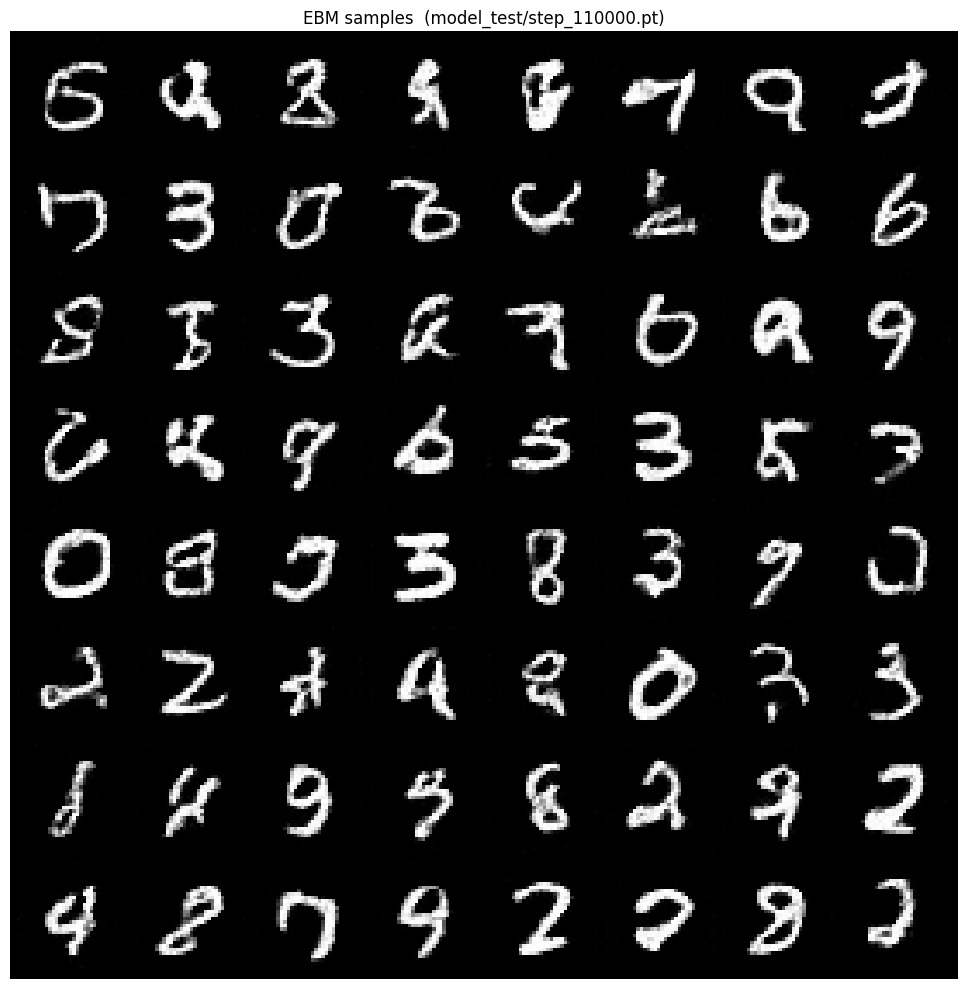

In [21]:
import torchvision

imgs = (samples.cpu().clamp(-1, 1) + 1) / 2
grid = torchvision.utils.make_grid(imgs, nrow=int(N_SAMPLES**0.5), padding=2)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
ax.axis('off')
ax.set_title('EBM samples  ({}/{})'.format(CHECKPOINT_PATH.parent.name, CHECKPOINT_PATH.name), fontsize=12)
plt.tight_layout()
plt.show()